In [ ]:
! pip install basemap

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Defines the haversine distance between 2 coordinates (useful for filtering by distance for certain crimes)"""
    # Convert degrees to radians
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)
    
    # Differences in coordinates
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    
    # Haversine formula
    a = np.sin(delta_lat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    # Earth radius in kilometers (mean radius for WGS84)
    R = 6371.0
    distance = R * c
    
    return distance

In [4]:
crimeData = pd.read_csv("./Data/Clean/crime-data.csv")

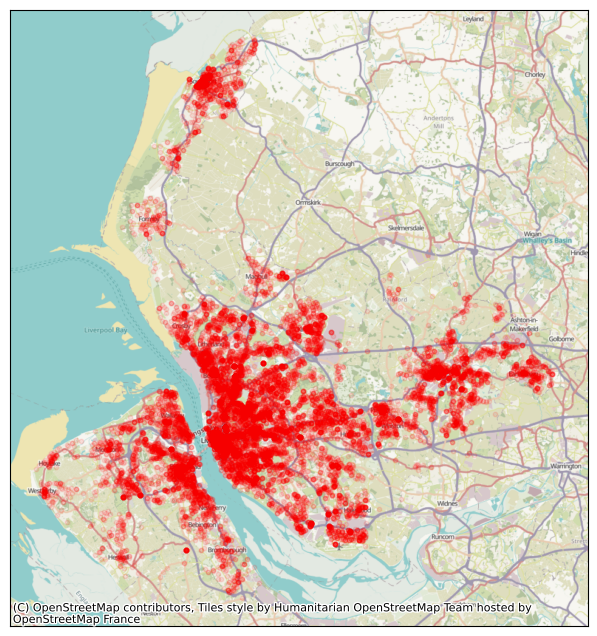

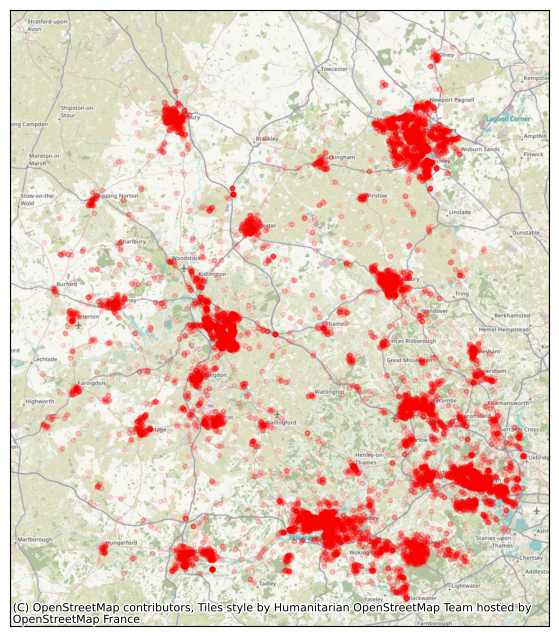

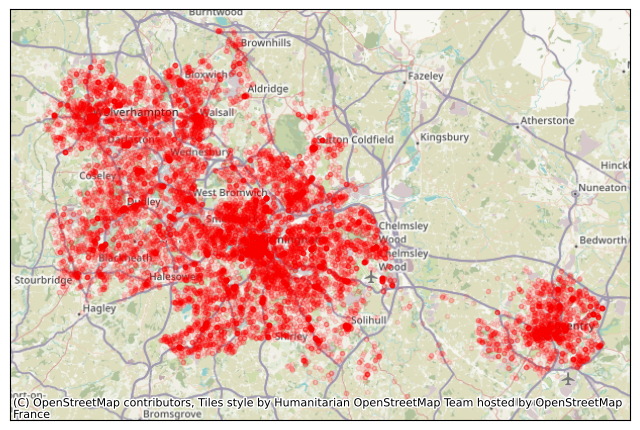

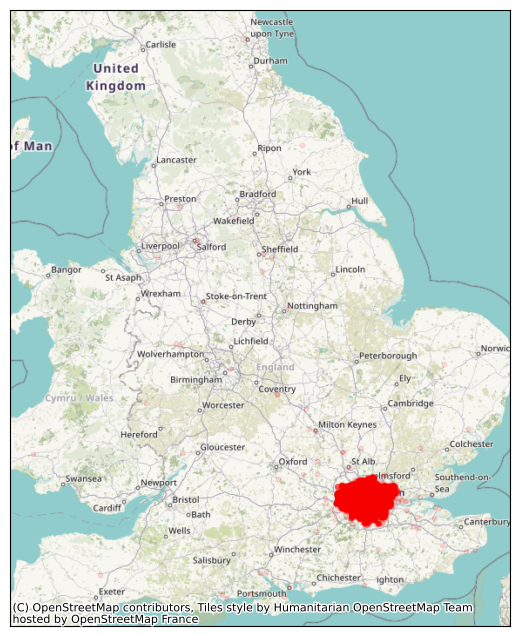

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

POLICE_FORCES = ["Merseyside Police", "Thames Valley Police", "West Midlands Police", "Metropolitan Police Service"]
# Example coordinates (lon, lat)

for force in POLICE_FORCES:
    positions = list(crimeData[crimeData["Falls within"] == force][["Longitude", "Latitude"]].itertuples(index=False, name=None))
    idxs = np.random.choice(len(positions), 20000)
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        [positions[idx] for idx in idxs],
        columns=["lon", "lat"],
        geometry=[Point(lon, lat) for lon, lat in [positions[idx] for idx in idxs]],
        crs="EPSG:4326"
    )

    # Convert to web mercator (required for OSM tiles)
    gdf = gdf.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(8,8))
    gdf.plot(ax=ax, color="red", alpha=0.1, markersize=10)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Add OpenStreetMap basemap
    ctx.add_basemap(ax)

    plt.show()